In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/new-plant-diseases-dataset


## Dataset Path Explanation

- When running this notebook **on Kaggle Notebooks**, the dataset is automatically mounted under the `/kaggle/input/` directory.  
- Therefore, to access the data, use paths starting with `/kaggle/input/...` followed by the folder structure inside the dataset.  
- For example, the train folder path would be inside a nested folder like:  
  `/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train`

- **If running locally or outside Kaggle**, where you have manually downloaded the dataset using `kagglehub`, the dataset will be stored in a local cache path like:  
  `/root/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/...`

- For simplicity and smooth running inside Kaggle notebooks, **we will use the Kaggle input path** for all data loading and processing steps.


In [2]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import glob as gb
import cv2

base_path = '/kaggle/input/new-plant-diseases-dataset/'
nested_path = os.path.join(base_path, 'New Plant Diseases Dataset(Augmented)', 'New Plant Diseases Dataset(Augmented)')

2025-06-08 16:29:16.391319: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749400156.590253      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749400156.646414      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
train = os.path.join(nested_path, 'train')

print(f"Train folder path set to: {train}")
print(f"Contents of train folder: {os.listdir(train)[:5]}")  # show first 5 classes

Train folder path set to: /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
Contents of train folder: ['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy']


In [4]:
size = 224
train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=90,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    rescale=1./255
).flow_from_directory(
    train,
    target_size=(size, size),
    batch_size=164,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=True
)


Found 70295 images belonging to 38 classes.


In [11]:
train_generator.class_indices

{'Apple___Apple_scab': 0,
 'Apple___Black_rot': 1,
 'Apple___Cedar_apple_rust': 2,
 'Apple___healthy': 3,
 'Blueberry___healthy': 4,
 'Cherry_(including_sour)___Powdery_mildew': 5,
 'Cherry_(including_sour)___healthy': 6,
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7,
 'Corn_(maize)___Common_rust_': 8,
 'Corn_(maize)___Northern_Leaf_Blight': 9,
 'Corn_(maize)___healthy': 10,
 'Grape___Black_rot': 11,
 'Grape___Esca_(Black_Measles)': 12,
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13,
 'Grape___healthy': 14,
 'Orange___Haunglongbing_(Citrus_greening)': 15,
 'Peach___Bacterial_spot': 16,
 'Peach___healthy': 17,
 'Pepper,_bell___Bacterial_spot': 18,
 'Pepper,_bell___healthy': 19,
 'Potato___Early_blight': 20,
 'Potato___Late_blight': 21,
 'Potato___healthy': 22,
 'Raspberry___healthy': 23,
 'Soybean___healthy': 24,
 'Squash___Powdery_mildew': 25,
 'Strawberry___Leaf_scorch': 26,
 'Strawberry___healthy': 27,
 'Tomato___Bacterial_spot': 28,
 'Tomato___Early_blight': 29,
 'Toma

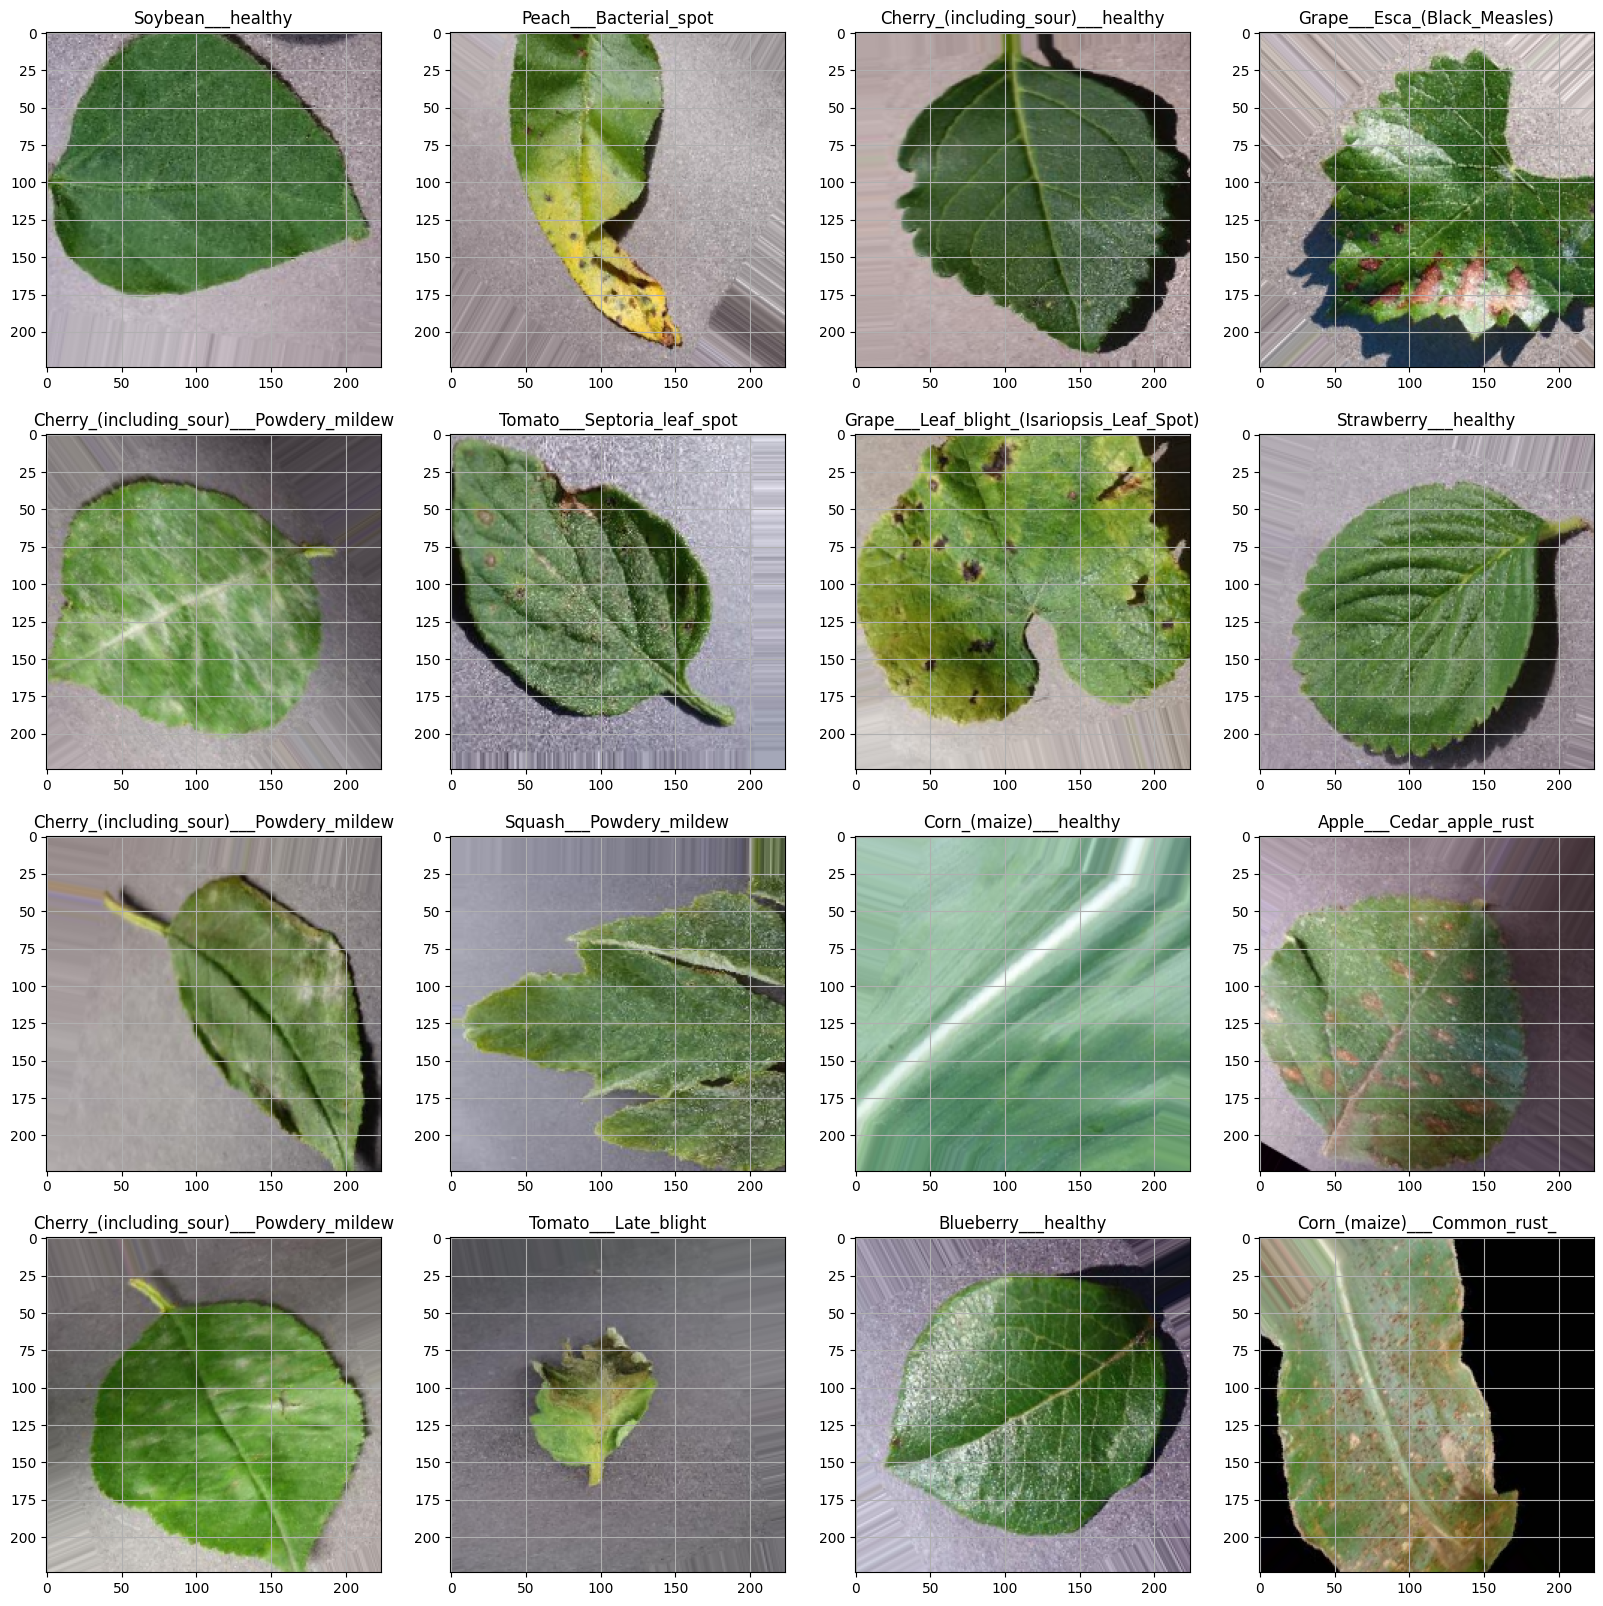

In [12]:
# Display some images
classes = list(train_generator.class_indices.keys())
plt.figure(figsize=(20,20))
for X_batch, y_batch in train_generator:
  for i in range(0, 16):
    plt.subplot(4, 4, i+1)
    plt.imshow(X_batch[i])
    plt.title(classes[np.where(y_batch[i]==1)[0][0]])
    plt.grid(None)
  plt.show()
  break

In [5]:
valid=os.path.join(nested_path, 'valid')

In [6]:
from sklearn.model_selection import train_test_split
import shutil
import os

# Paths
original_valid_dir = valid
new_valid_dir = '/kaggle/working/new_valid'
test_dir = '/kaggle/working/test'

# Create folders
os.makedirs(new_valid_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# For each class, split into new valid and test sets
for class_name in os.listdir(original_valid_dir):
    class_path = os.path.join(original_valid_dir, class_name)
    if os.path.isdir(class_path):
        imgs = os.listdir(class_path)
        train_imgs, test_imgs = train_test_split(imgs, test_size=0.5, random_state=42)

        os.makedirs(os.path.join(new_valid_dir, class_name), exist_ok=True)
        os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)

        for img in train_imgs:
            shutil.copy(os.path.join(class_path, img), os.path.join(new_valid_dir, class_name, img))
        for img in test_imgs:
            shutil.copy(os.path.join(class_path, img), os.path.join(test_dir, class_name, img))


In [7]:
# Load New Validation Set
valid_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255).flow_from_directory(
    new_valid_dir,
    target_size=(size, size),
    batch_size=164,
    class_mode='categorical',
    shuffle=False
)

# Load Test Set
test_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,
    target_size=(size, size),
    batch_size=164,
    class_mode='categorical',
    shuffle=False
)


Found 8777 images belonging to 38 classes.
Found 8795 images belonging to 38 classes.


In [16]:
test_33 = '/kaggle/input/new-plant-diseases-dataset/test'

# 📊 Class Distribution in the Training Dataset

To understand the balance of our dataset across different plant disease classes, I counted the number of images per class in the training folder and visualized it as a bar chart.

This helps us see if some classes have significantly fewer or more images, which might affect how well the model learns each class.

---

### How the data looks:

- Most classes have around 1,750 images — a very uniform distribution.
- A few classes, especially some apple diseases, have slightly more (~2,000 images).
- Some classes like blueberry and cherry have a bit fewer (~1,500 images).

Overall, the dataset is quite balanced, which is great for training a robust model.

---

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


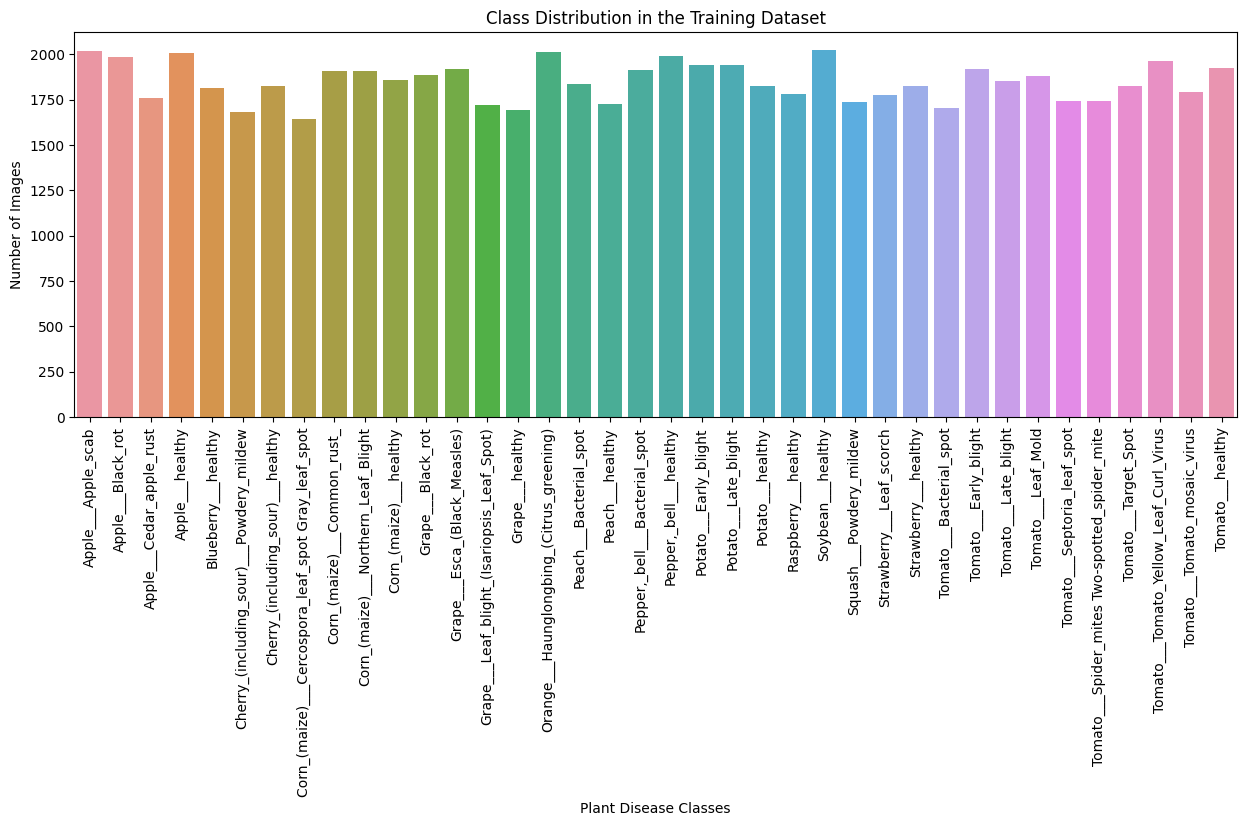

In [8]:
import seaborn as sns

class_counts = {k: len(os.listdir(os.path.join(train, k))) for k in train_generator.class_indices.keys()}
plt.figure(figsize=(15,5))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.xticks(rotation=90)
plt.xlabel("Plant Disease Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution in the Training Dataset")
plt.show()


# Validation Dataset Class Distribution – What I Found

Alright, so I checked out the validation dataset to see how the classes compare with the training set we looked at before. Here’s what I noticed:

---

### Quick Breakdown

For every class, the number of images in validation is roughly **20%** of what we have in training. So if a class had about 1600 images in training, validation has around 320. Makes sense for a good train-validation split.

Here’s how it looks for some key classes (all approximate):

- **Apple___Apple_scab** — Train: ~2000 images, Valid: ~400  
- **Apple___Black_rot** — Train: ~1900 images, Valid: ~380  
- **Apple___healthy** — Train: ~1700 images, Valid: ~340  
- **Blueberry___healthy** — Train: ~1600 images, Valid: ~320  
- **Tomato___Late_blight** — Train: ~1600 images, Valid: ~300  
- **Tomato___healthy** — Train: ~1600 images, Valid: ~320  

Basically, the validation set is like a mini-me of the training set, keeping the proportions tight across all 38 classes.

---

### What This Means

- **Balanced Representation:** Validation has both diseased and healthy classes well covered, which is super important to test if the model is actually learning to tell the difference.

- **No Weird Skews:** None of the classes got shafted with barely any validation images, so we don’t have to worry about biased eval results.

- **Enough Data:** Each class has enough images in validation to make the evaluation legit and reliable.

---

### Overall Takeaway

The validation dataset is solid — it mirrors the training set pretty well and keeps things balanced. This should help us confidently check how well our model performs and avoid overfitting.




/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


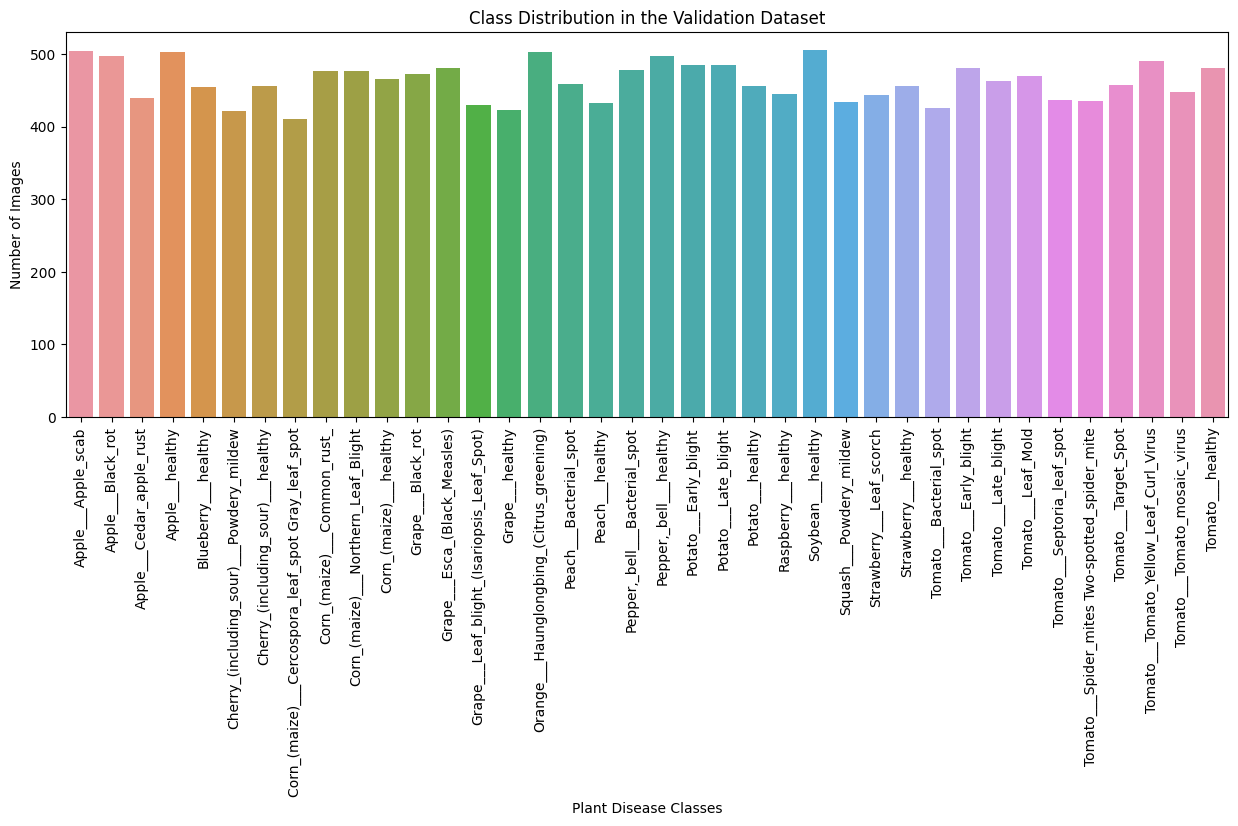

In [10]:
valid_class_counts = {k: len(os.listdir(os.path.join(valid, k))) for k in train_generator.class_indices.keys()}

# Plotting
plt.figure(figsize=(15,5))
sns.barplot(x=list(valid_class_counts.keys()), y=list(valid_class_counts.values()))
plt.xticks(rotation=90)
plt.xlabel("Plant Disease Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution in the Validation Dataset")
plt.show()
#do for test folder too

In [ ]:
#used for data cleaning

'''def find_corrupt_images(folder_path):
    corrupt_images = []
    for class_name in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_name)
        if not os.path.isdir(class_path):
            continue
        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)
            img = cv2.imread(image_path)
            if img is None:
                corrupt_images.append(image_path)
    return corrupt_images

print(f"Checking train folder: {train}")
train_corrupt = find_corrupt_images(train)
print(f"Found {len(train_corrupt)} corrupt images in train folder.")

print(f"Checking valid folder: {valid}")
valid_corrupt = find_corrupt_images(valid)
print(f"Found {len(valid_corrupt)} corrupt images in valid folder.")

print(f"Checking test folder: {test}")
test_corrupt = find_corrupt_images(test)
print(f"Found {len(test_corrupt)} corrupt images in test folder.")

if train_corrupt:
    print("Example corrupt images in train:", train_corrupt[:5])
if valid_corrupt:
    print("Example corrupt images in valid:", valid_corrupt[:5])
if test_corrupt:
    print("Example corrupt images in test:", test_corrupt[:5])'''


In [ ]:
'''import os
import hashlib
from collections import defaultdict
from PIL import Image

# Define your paths
train_path =train
valid_path = valid
test_path = test

all_paths = {'Train': train_path, 'Valid': valid_path, 'Test': test_path}

def get_image_hash(image_path):
    try:
        with Image.open(image_path) as img:
            img = img.resize((128, 128)).convert('RGB')  # Normalize for hashing
            return hashlib.md5(img.tobytes()).hexdigest()
    except:
        return None  # If image is unreadable

for name, folder_path in all_paths.items():
    print(f"\n🔍 Checking folder: {name} — {folder_path}")
    seen_hashes = defaultdict(list)
    inconsistent_folders = []

    for class_folder in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_folder)

        # Check folder name format
        if "__" not in class_folder and "healthy" not in class_folder:
            inconsistent_folders.append(class_folder)

        for image_file in os.listdir(class_path):
            image_path = os.path.join(class_path, image_file)
            img_hash = get_image_hash(image_path)
            if img_hash:
                seen_hashes[img_hash].append(image_path)

    # Duplicate Detection
    duplicates = {h: p for h, p in seen_hashes.items() if len(p) > 1}
    print(f"🧬 Total duplicate image groups: {len(duplicates)}")
    if duplicates:
        print(f"🔁 Example duplicate set:\n{list(duplicates.values())[0][:3]}")

    # Folder naming check
    if inconsistent_folders:
        print(f"⚠️ Inconsistent class folder names:\n{inconsistent_folders}")
    else:
        print("✅ All class folder names look clean.")'''


In [ ]:
#used for EDA
'''import os
import cv2
import random
import matplotlib.pyplot as plt
from collections import Counter

def eda_inspect(data_path, folder_name="Dataset"):
    print(f"🔍 EDA for {folder_name} at: {data_path}")
    
    # 1. Class distribution
    classes = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    class_counts = {}
    for cls in classes:
        class_dir = os.path.join(data_path, cls)
        class_counts[cls] = len([f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f"📊 Class distribution ({len(classes)} classes):")
    for cls, count in sorted(class_counts.items(), key=lambda x: x[1], reverse=True):
        print(f"  - {cls}: {count} images")
    
    # 2. Image size distribution
    widths, heights = [], []
    img_formats = Counter()
    sample_images = []
    
    for cls in classes:
        class_dir = os.path.join(data_path, cls)
        images = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        # Take 5 random samples from each class for visualization
        sample_images.extend(random.sample([os.path.join(class_dir, img) for img in images], 
                                           min(5, len(images))))
        for img_name in images:
            img_path = os.path.join(class_dir, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                h, w = img.shape[:2]
                widths.append(w)
                heights.append(h)
                ext = img_name.split('.')[-1].lower()
                img_formats[ext] += 1
    
    print(f"\n📏 Image size stats:")
    print(f"  - Width: min={min(widths)}, max={max(widths)}, mean={sum(widths)//len(widths)}")
    print(f"  - Height: min={min(heights)}, max={max(heights)}, mean={sum(heights)//len(heights)}")
    
    print(f"\n🖼️ Image formats distribution:")
    for fmt, count in img_formats.items():
        print(f"  - {fmt}: {count} images")
    
    # 3. Show random samples per class (max 5 per class, max 20 images total)
    print(f"\n🎨 Random samples from the dataset:")
    plt.figure(figsize=(15, 10))
    sample_images = random.sample(sample_images, min(20, len(sample_images)))
    for i, img_path in enumerate(sample_images):
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        plt.subplot(4, 5, i+1)
        plt.imshow(img)
        plt.title(os.path.basename(os.path.dirname(img_path)))
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Example usage:
eda_inspect(train, folder_name="Train")
eda_inspect(valid, folder_name="Validation")
eda_inspect(test, folder_name="Test")'''


In [19]:
from tensorflow import keras

model = keras.models.Sequential()

model.add(keras.layers.Conv2D(filters=32, kernel_size=7, strides=1, padding='same',
                              activation='relu', name="Conv1", input_shape=(224, 224, 3)))
model.add(keras.layers.MaxPool2D(pool_size=2, name="Pool1"))

model.add(keras.layers.Conv2D(filters=64, kernel_size=5, strides=1, padding='same',
                              activation='relu', name='Conv2'))
model.add(keras.layers.MaxPool2D(pool_size=2, name="Pool2"))

model.add(keras.layers.Conv2D(filters=128, kernel_size=3, strides=1, padding='same',
                              activation='relu', name='Conv3'))
model.add(keras.layers.MaxPool2D(pool_size=2, name="Pool3"))

model.add(keras.layers.Conv2D(filters=256, kernel_size=3, strides=1, padding='same',
                              activation='relu', name='Conv4'))
model.add(keras.layers.MaxPool2D(pool_size=2, name="Pool4"))  # Important!

model.add(keras.layers.Flatten(name='Flatten1'))

model.add(keras.layers.Dense(128, activation='relu', name='Dense1'))
model.add(keras.layers.Dropout(0.5))  # Correctly added dropout

model.add(keras.layers.Dense(64, activation='relu', name='Dense2'))
model.add(keras.layers.Dropout(0.5))  # Correctly added dropout

model.add(keras.layers.Dense(38, activation='softmax', name='Output'))

print(model.summary())


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1749366735.016167      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                       │ (None, 224, 224, 32)        │           4,736 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Pool1 (MaxPooling2D)                 │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv2 (Conv2D)                       │ (None, 112, 112, 64)        │          51,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Pool2 (MaxPooling2D)                 │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv3 (Conv2D)                       │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Pool3 (MaxPooling2D)                 │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv4 (Conv2D)                       │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Pool4 (MaxPooling2D)                 │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Flatten1 (Flatten)                   │ (None, 50176)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dense1 (Dense)                       │ (None, 128)                 │       6,422,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dense2 (Dense)                       │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Output (Dense)                       │ (None, 38)                  │           2,470 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,858,406 (26.16 MB)

 Trainable params: 6,858,406 (26.16 MB)

 Non-trainable params: 0 (0.00 B)

None


In [21]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    'best_modelv1.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

model_reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

callbacks = [early_stopping, model_checkpoint, model_reduce_lr]


In [22]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)


In [23]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available: 1


In [24]:
history = model.fit(train_generator, epochs=20, validation_data=valid_generator, callbacks=callbacks)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1749366826.925959     161 service.cc:148] XLA service 0x79fe5c010ab0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749366826.926784     161 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1749366827.433132     161 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-06-08 07:13:58.545417: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng0{} for conv (f32[32,3,7,7]{3,2,1,0}, u8[0]{0}) custom-call(f32[164,3,224,224]{3,2,1,0}, f32[164,32,224,224]{3,2,1,0}), window={size=7x7 pad=3_3x3_3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-06-08 07:13:59.406673: E external/l

  1/429 ━━━━━━━━━━━━━━━━━━━━ 3:32:46 30s/step - accuracy: 0.0183 - auc: 0.4835 - loss: 3.6391 - precision: 0.0000e+00 - recall: 0.0000e+00

I0000 00:00:1749366849.232844     161 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


254/429 ━━━━━━━━━━━━━━━━━━━━ 11:30 4s/step - accuracy: 0.0362 - auc: 0.5237 - loss: 3.6305 - precision: 0.5101 - recall: 0.0047

2025-06-08 07:30:56.398665: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng0{} for conv (f32[32,3,7,7]{3,2,1,0}, u8[0]{0}) custom-call(f32[103,3,224,224]{3,2,1,0}, f32[103,32,224,224]{3,2,1,0}), window={size=7x7 pad=3_3x3_3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-06-08 07:30:56.534780: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.136213614s
Trying algorithm eng0{} for conv (f32[32,3,7,7]{3,2,1,0}, u8[0]{0}) custom-call(f32[103,3,224,224]{3,2,1,0}, f32[103,32,224,224]{3,2,1,0}), window={size=7x7 pad=3_3x3_3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", backend_config={"cudnn_conv_backend_config":{"act

429/429 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.0443 - auc: 0.5521 - loss: 3.5858 - precision: 0.6145 - recall: 0.0074
Epoch 1: val_loss improved from inf to 3.25469, saving model to best_modelv1.keras
429/429 ━━━━━━━━━━━━━━━━━━━━ 1725s 4s/step - accuracy: 0.0443 - auc: 0.5523 - loss: 3.5855 - precision: 0.6148 - recall: 0.0074 - val_accuracy: 0.1322 - val_auc: 0.7260 - val_loss: 3.2547 - val_precision: 0.9000 - val_recall: 0.0215 - learning_rate: 0.0010
Epoch 2/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1461 - auc: 0.7907 - loss: 3.0308 - precision: 0.7022 - recall: 0.0290
Epoch 2: val_loss improved from 3.25469 to 2.19515, saving model to best_modelv1.keras
429/429 ━━━━━━━━━━━━━━━━━━━━ 1000s 2s/step - accuracy: 0.1462 - auc: 0.7908 - loss: 3.0303 - precision: 0.7021 - recall: 0.0290 - val_accuracy: 0.3477 - val_auc: 0.9203 - val_loss: 2.1952 - val_precision: 0.8776 - val_recall: 0.0768 - learning_rate: 0.0010
Epoch 3/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - ac

In [27]:
# Load your saved best model
model = keras.models.load_model('best_modelv1.keras')

# Then continue training from that checkpoint 
history = model.fit(
    train_generator,
    epochs=5,  
    validation_data=valid_generator,
    callbacks=callbacks
)


Epoch 1/5
429/429 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8519 - auc: 0.9920 - loss: 0.4906 - precision: 0.9026 - recall: 0.8063
Epoch 1: val_loss improved from 0.19023 to 0.18886, saving model to best_modelv1.keras
429/429 ━━━━━━━━━━━━━━━━━━━━ 886s 2s/step - accuracy: 0.8519 - auc: 0.9920 - loss: 0.4906 - precision: 0.9026 - recall: 0.8063 - val_accuracy: 0.9378 - val_auc: 0.9982 - val_loss: 0.1889 - val_precision: 0.9552 - val_recall: 0.9232 - learning_rate: 0.0010
Epoch 2/5
429/429 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8582 - auc: 0.9930 - loss: 0.4666 - precision: 0.9073 - recall: 0.8142
Epoch 2: val_loss improved from 0.18886 to 0.18031, saving model to best_modelv1.keras
429/429 ━━━━━━━━━━━━━━━━━━━━ 867s 2s/step - accuracy: 0.8582 - auc: 0.9930 - loss: 0.4665 - precision: 0.9073 - recall: 0.8142 - val_accuracy: 0.9425 - val_auc: 0.9979 - val_loss: 0.1803 - val_precision: 0.9569 - val_recall: 0.9289 - learning_rate: 0.0010
Epoch 3/5
429/429 ━━━━━━━━━━━━━━━━━━━━ 0s 2s

54/54 ━━━━━━━━━━━━━━━━━━━━ 23s 395ms/step - accuracy: 0.9529 - auc: 0.9989 - loss: 0.1526 - precision: 0.9639 - recall: 0.9369
🔍 Test Accuracy: 0.9508
🔍 Test AUC: 0.9659
🔍 Test Precision: 0.9344
🔍 Test Recall: 0.9990
🔍 Test Loss: 0.1611
54/54 ━━━━━━━━━━━━━━━━━━━━ 18s 327ms/step

🧾 Classification Report:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.96      0.90      0.93       252
                                 Apple___Black_rot       0.96      0.97      0.96       249
                          Apple___Cedar_apple_rust       0.98      0.97      0.97       220
                                   Apple___healthy       0.96      0.95      0.95       251
                               Blueberry___healthy       0.95      0.99      0.97       227
          Cherry_(including_sour)___Powdery_mildew       0.95      0.99      0.97       211
                 Cherry_(including_sour)___health

/tmp/ipykernel_35/3072597776.py:39: UserWarning: Glyph 128311 (\N{LARGE BLUE DIAMOND}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128311 (\N{LARGE BLUE DIAMOND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


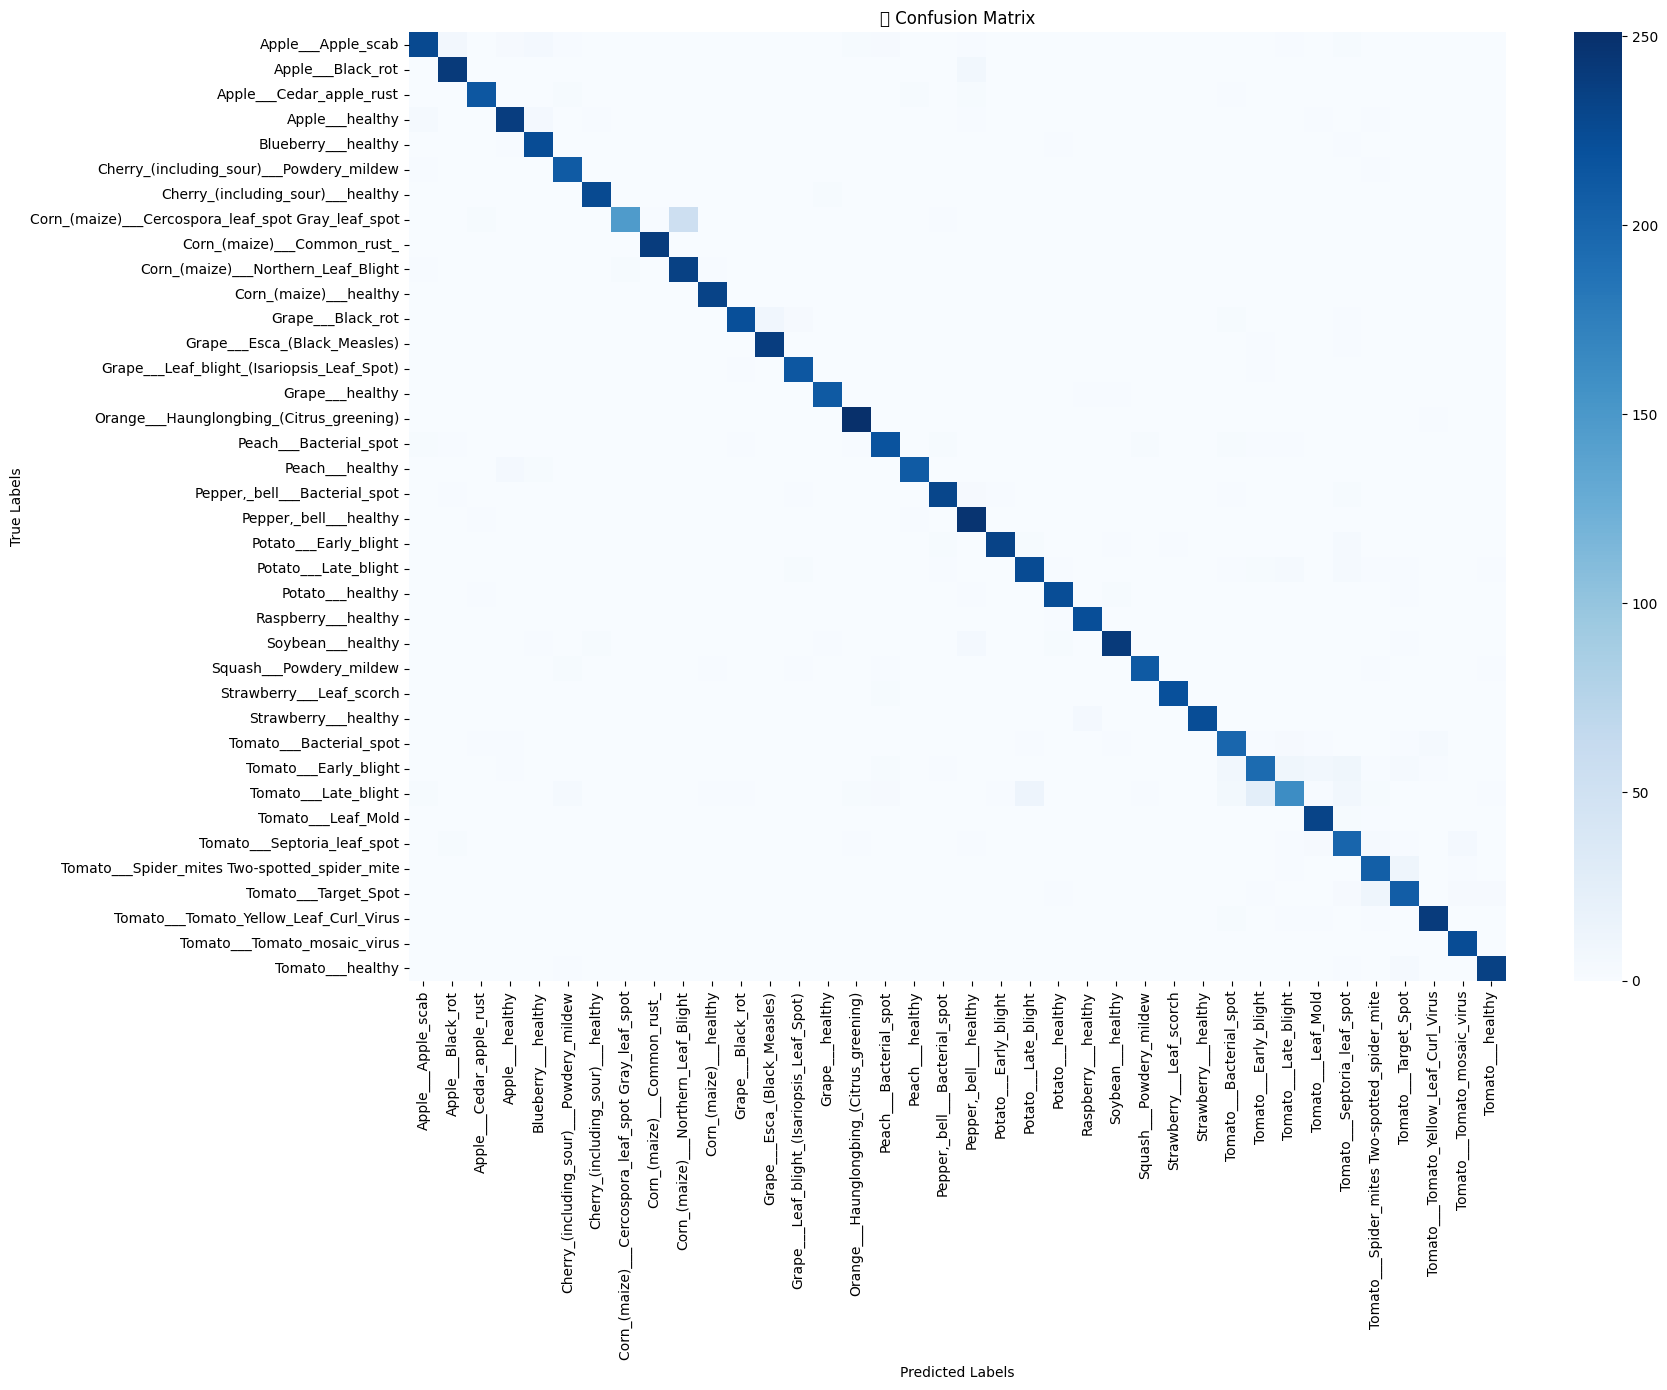

📌 Macro F1 Score: 0.9498
📌 Mean Squared Error (MSE): 4.6080


In [28]:
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_squared_error, roc_auc_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 🔹 Load the best model
model = load_model("best_modelv1.keras")

# 🔹 Evaluate on test data
test_loss, test_accuracy, test_auc, test_precision, test_recall = model.evaluate(test_generator, verbose=1)
print(f"🔍 Test Accuracy: {test_accuracy:.4f}")
print(f"🔍 Test AUC: {test_auc:.4f}")
print(f"🔍 Test Precision: {test_precision:.4f}")
print(f"🔍 Test Recall: {test_recall:.4f}")
print(f"🔍 Test Loss: {test_loss:.4f}")

# 🔹 Predictions
y_probs = model.predict(test_generator)
y_preds = np.argmax(y_probs, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# 🔹 Classification report
print("\n🧾 Classification Report:\n")
print(classification_report(y_true, y_preds, target_names=class_labels))

# 🔹 Confusion matrix
conf_mat = confusion_matrix(y_true, y_preds)

plt.figure(figsize=(18, 14))
sns.heatmap(conf_mat, annot=False, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title("🔷 Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 🔹 Extra Metrics (optional but spicy)
f1 = f1_score(y_true, y_preds, average='macro')
mse = mean_squared_error(y_true, y_preds)
print(f"📌 Macro F1 Score: {f1:.4f}")
print(f"📌 Mean Squared Error (MSE): {mse:.4f}")

# You can also calculate per-class precision, recall, etc. from classification_report if needed


In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    'best_modelv2effnet.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

model_reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

callbacks = [early_stopping, model_checkpoint, model_reduce_lr]


In [15]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Input image size
size = 224

# Load EfficientNetB0 base model with pretrained ImageNet weights, exclude top layer
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(size, size, 3)
)

# Freeze the base model initially (for transfer learning)
base_model.trainable = False

# Build the top layers for your classification task
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)  # regularization
output = Dense(train_generator.num_classes, activation='softmax')(x)

# Define the complete model
model = Model(inputs=base_model.input, outputs=output)

# Compile the model with Adam optimizer and same metrics you used earlier
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        'precision',
        'recall',
        'AUC'
    ]
)

# Summary to check architecture
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_4 (Rescaling)   │ (None, 224, 224, 3)    │              0 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization_2           │ (None, 224, 224, 3)    │              7 │ rescaling_4[0][0]      │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_5 (Rescaling)   │ (None, 224, 224, 3)    │              0 │ normalization_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv_pad             │ (None, 225, 225, 3)    │              0 │ rescaling_5[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 112, 112, 32)   │            864 │ stem_conv_pad[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 112, 112, 32)   │            128 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 112, 112, 32)   │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_dwconv            │ (None, 112, 112, 32)   │            288 │ stem_activation[0][0]  │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_bn                │ (None, 112, 112, 32)   │            128 │ block1a_dwconv[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_activation        │ (None, 112, 112, 32)   │              0 │ block1a_bn[0][0]       │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_squeeze        │ (None, 32)             │              0 │ block1a_activation[0]… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reshape        │ (None, 1, 1, 32)       │              0 │ block1a_se_squeeze[0]… │
│ (Reshape)                 │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reduce         │ (None, 1, 1, 8)        │            264 │ block1a_se_reshape[0]… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 4,098,249 (15.63 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1749401047.878984     120 service.cc:148] XLA service 0x783f60013d20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749401047.879810     120 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1749401049.788652     120 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1749401056.926757     120 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1749401057.132816     120 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1749401058.050941     120 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1749401058.2743

  1/429 ━━━━━━━━━━━━━━━━━━━━ 4:16:24 36s/step - AUC: 0.5063 - accuracy: 0.0244 - loss: 3.6703 - precision: 0.0000e+00 - recall: 0.0000e+00

I0000 00:00:1749401065.433046     120 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


429/429 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - AUC: 0.5040 - accuracy: 0.0271 - loss: 3.6714 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 1: val_loss improved from inf to 3.65578, saving model to best_modelv2effnet.keras
429/429 ━━━━━━━━━━━━━━━━━━━━ 1151s 3s/step - AUC: 0.5040 - accuracy: 0.0271 - loss: 3.6714 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_AUC: 0.5035 - val_accuracy: 0.0251 - val_loss: 3.6558 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - AUC: 0.5067 - accuracy: 0.0272 - loss: 3.6647 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 2: val_loss did not improve from 3.65578
429/429 ━━━━━━━━━━━━━━━━━━━━ 881s 2s/step - AUC: 0.5067 - accuracy: 0.0272 - loss: 3.6647 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_AUC: 0.5027 - val_accuracy: 0.0264 - val_loss: 3.6598 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 0s